In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
from sklearn.datasets import make_blobs

# Создание набора данных

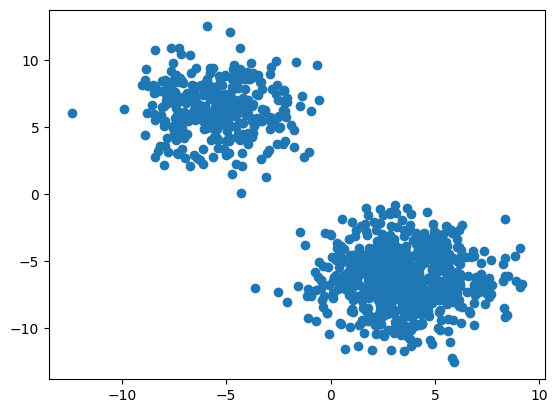

In [3]:
data = make_blobs(
  n_samples=1000,
  n_features=2,
  centers=3,
  cluster_std=2
)[0]
plt.scatter(data[:, 0], data[:, 1])
plt.show()

# Определение кластеров

In [4]:
from sklearn.cluster import KMeans

In [5]:
# Define kmeans
kmeans = KMeans(3)

In [6]:
# Fir kmeans
kmeans.fit(data)

KMeans(n_clusters=3)

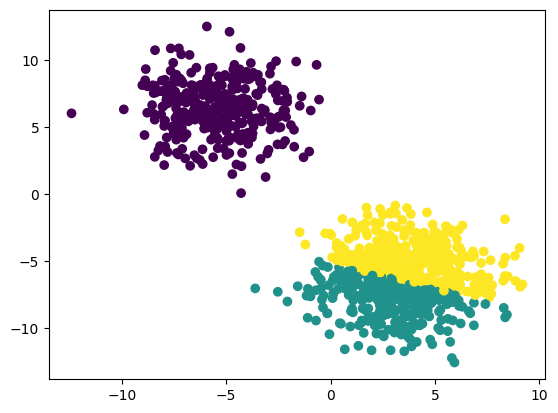

In [7]:
plt.scatter(data[:, 0], data[:, 1], c=kmeans.predict(data))
plt.show()

# Decision Tree

In [8]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [9]:
def function(x):
  return np.sin(x) + np.random.rand(*x.shape)

In [10]:
data = np.expand_dims(np.linspace(-5, 5, 1000), 1)
test_data = np.expand_dims(np.linspace(-5, 5, 760), 1)
y = function(data)[:, 0]
test_y = function(test_data)[:, 0]

In [11]:
# Объявление дерева решений
# Обратите внимание, что необходимо подобрать параметры, для того чтобы дерео не переобучилось
model_dt = DecisionTreeRegressor()
model_dt.fit(data, y)
model_rf = RandomForestRegressor()
model_rf.fit(data, y)

RandomForestRegressor()

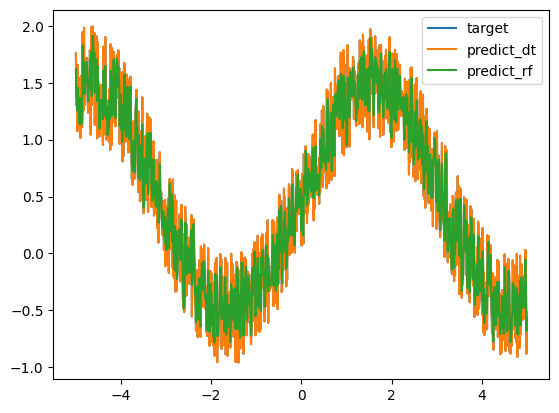

In [12]:
plt.plot(data[:, 0], y, label="target")
plt.plot(data[:, 0], model_dt.predict(data), label="predict_dt")
plt.plot(data[:, 0], model_rf.predict(data), label="predict_rf")
plt.legend()
plt.show()

In [13]:
# В случае если оценка train значительно меньше оценки test, можно понять что модель переобучилась
print("DecisionTreeRegressor")
print(f"MSE train: {np.power(model_dt.predict(data) - y, 2).mean()}")
print(f"MSE test: {np.power(model_dt.predict(test_data) - test_y, 2).mean()}")

print("RandomForestRegressor")
print(f"MSE train: {np.power(model_rf.predict(data) - y, 2).mean()}")
print(f"MSE test: {np.power(model_rf.predict(test_data) - test_y, 2).mean()}")

DecisionTreeRegressor
MSE train: 0.0
MSE test: 0.16762206824693862
RandomForestRegressor
MSE train: 0.016828782034716622
MSE test: 0.1213750991367462
